# Studio dataset

link:https://cs.stanford.edu/people/dorarad/gqa/download.html

In [4]:
import json
import random
import pandas as pd

#pd.set_option("display.max_colwidth", None)
#pd.set_option("display.max_rows", None)
#pd.set_option("display.max_columns", None)

with open("../data/sceneGraphs/val_sceneGraphs.json") as f:
    data = json.load(f)

# 🔥 tutte le chiavi senza filtro
all_keys = list(data.keys())

print(f"Totale record: {len(all_keys)}")

random.seed(42)

keys = random.sample(all_keys, 1)
small_data = {k: data[k] for k in keys}

df = pd.DataFrame.from_dict(small_data, orient="index")
df.reset_index(inplace=True)
df.rename(columns={"index": "image_id"}, inplace=True)

Totale record: 10696


In [5]:
display(df.head())

,image_id,width,objects,height
0,2406772,500,"{'3811381': {'name': 'pole', 'h': 23, 'relatio...",375


In [ ]:
#print(df["location"].drop_duplicates().to_string(index=False))

KeyError: 'location'

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_image_grid_from_df(df, image_dir, cols=5, id_col="image_id", max_images=25):
    """
    Mostra una griglia di immagini prendendo gli ID da un DataFrame.
    """

    df_small = df.head(max_images)

    image_ids = df_small[id_col].tolist()

    rows = (len(image_ids) + cols - 1) // cols

    plt.figure(figsize=(15, 3 * rows))

    for i, image_id in enumerate(image_ids):

        img_path = os.path.join(image_dir, f"{image_id}.jpg")

        # sicurezza: se immagine non esiste, skip
        if not os.path.exists(img_path):
            print(f"Missing: {img_path}")
            continue

        img = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(str(image_id), fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

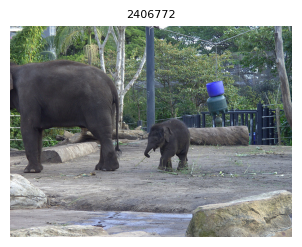

In [8]:
show_image_grid_from_df(
    df=df,
    image_dir="../data/images",
    cols=5,
    max_images=10
)

In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_by_id(df, image_id, image_dir, id_col="image_id"):
    
    # 1. trova la riga
    row = df[df[id_col] == str(image_id)]

    if row.empty:
        print(f"Image ID {image_id} non trovato nel DataFrame")
        return

    row = row.iloc[0]

    # 2. stampa informazioni
    print("📌 Informazioni record:")
    print(row)
    print("\n")

    # 3. carica immagine
    img_path = os.path.join(image_dir, f"{image_id}.jpg")

    if not os.path.exists(img_path):
        print(f"Immagine non trovata: {img_path}")
        return

    img = Image.open(img_path).convert("RGB")

    # 4. mostra immagine
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Image ID: {image_id}")
    plt.axis("off")
    plt.show()

📌 Informazioni record:
image_id                                              2406772
width                                                     500
objects     {'3811381': {'name': 'pole', 'h': 23, 'relatio...
height                                                    375
Name: 0, dtype: object




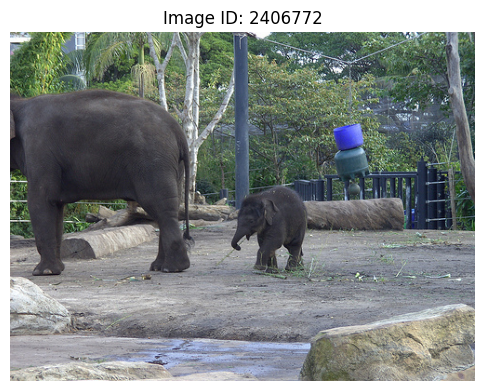

In [10]:
show_sample_by_id(
    df=df,
    image_id=2406772,
    image_dir="../data/images"
)

In [11]:
import pandas as pd

def extract_objects(df, col_input, col_output="objects"):
    """
    Estrae i nomi degli oggetti da un scene graph GQA
    e rimuove i duplicati mantenendo l'ordine.
    """

    def get_objects(scene_graph):
        if not isinstance(scene_graph, dict):
            return []

        objects = []
        seen = set()

        for obj_id, obj_data in scene_graph.items():
            if isinstance(obj_data, dict) and "name" in obj_data:
                name = obj_data["name"]

                if name not in seen:
                    objects.append(name)
                    seen.add(name)

        return objects

    df[col_output] = df[col_input].apply(get_objects)

    return df

In [12]:
df_new = extract_objects(df, "objects","obj_list")

In [13]:
display(df_new.head(5))

,image_id,width,objects,height,obj_list
0,2406772,500,"{'3811381': {'name': 'pole', 'h': 23, 'relatio...",375,"[pole, legs, elephant, trunk, rock, ear, tail,..."


In [14]:
count = df_new["obj_list"].apply(
    lambda x: isinstance(x, list) and "living room" in x
).sum()

print(count)

0


In [21]:
display(df_clip.head(1)) 

,image_id,width,objects,height,obj_list,clip_room
0,2406772,500,"{'3811381': {'name': 'pole', 'h': 23, 'relatio...",375,"[pole, legs, elephant, trunk, rock, ear, tail,...",an outdoor scene


In [17]:
def count_rooms(df, col="objects"):
    """
    Conta quante immagini contengono ciascun tipo di stanza
    e calcola anche totale assegnato e non assegnato.
    """
    room_keywords = {
        # 🍳 KITCHEN
        "kitchen": {
            "oven", "refrigerator", "sink", "microwave", "stove",
            "kitchen", "counter", "cabinet", "dishwasher"
        },

        # 🛋 LIVING ROOM
        "living_room": {
            "sofa", "couch", "tv", "television", "coffee table",
            "armchair", "living room", "rug", "lamp", "bookshelf"
        },

        # 🛏 BEDROOM
        "bedroom": {
            "bed", "pillow", "blanket", "nightstand",
            "wardrobe", "bedroom", "dresser"
        },

        # 🚿 BATHROOM
        "bathroom": {
            "toilet", "bathtub", "shower", "bathroom",
            "mirror", "sink"
        },

        # 🍽 DINING ROOM
        "dining_room": {
            "dining table", "table", "chair", "plate",
            "cup", "food", "bowl", "dining room"
        },

        # 🧑‍💻 OFFICE
        "office": {
            "desk", "computer", "laptop", "monitor",
            "keyboard", "mouse", "chair", "office"
        },

        # 🚪 HALLWAY / CORRIDOR
        "hallway": {
            "door", "corridor", "hall", "hallway",
            "wall", "floor"
        },

        # 🏪 STORE / SHOP
        "store": {
            "shelf", "rack", "products", "store",
            "shop", "clothes", "display", "aisle"
        },

        # 🚗 GARAGE
        "garage": {
            "garage", "car", "vehicle", "door"
        },

        # 🌳 OUTDOOR / NATURE
        "outdoor": {
            "tree", "grass", "sky", "mountain",
            "water", "field", "forest", "road"
        },

        # 🚧 STREET / URBAN
        "street": {
            "car", "bus", "road", "street",
            "traffic light", "building", "sidewalk", "city"
        },

        # ❓ UNKNOWN / AMBIGUOUS
        "unknown": {
            "person", "man", "woman", "object"
        }
    }

    results = {}

    # 🔥 per calcolare assegnazione globale
    assigned_mask = df[col].apply(
        lambda objs: isinstance(objs, list) and any(
            obj in keywords
            for keywords in room_keywords.values()
            for obj in objs
        )
    )

    for room, keywords in room_keywords.items():

        count = df[col].apply(
            lambda objs: isinstance(objs, list) and any(obj in keywords for obj in objs)
        ).sum()

        results[room] = count

    # stampa risultati per stanza
    print("\n--- COUNT PER ROOM ---")
    for room, count in results.items():
        print(f"{room}: {count}")

    # 🔥 totali globali
    total_assigned = assigned_mask.sum()
    total_unassigned = len(df) - total_assigned

    print("\n--- GLOBAL ---")
    print(f"Totale immagini assegnate: {total_assigned}")
    print(f"Totale immagini NON assegnate: {total_unassigned}")
    print(f"Totale dataset: {len(df)}")

    return results

In [18]:
print(count_rooms(df_new, "obj_list"))


--- COUNT PER ROOM ---
kitchen: 0
living_room: 0
bedroom: 0
bathroom: 1
dining_room: 0
office: 0
hallway: 0
store: 0
garage: 0
outdoor: 0
street: 0
unknown: 0

--- GLOBAL ---
Totale immagini assegnate: 1
Totale immagini NON assegnate: 0
Totale dataset: 1
{'kitchen': 0, 'living_room': 0, 'bedroom': 0, 'bathroom': 1, 'dining_room': 0, 'office': 0, 'hallway': 0, 'store': 0, 'garage': 0, 'outdoor': 0, 'street': 0, 'unknown': 0}


In [19]:
import matplotlib.pyplot as plt
import os
from PIL import Image

def show_images_per_room(df, images_path, col="objects", n=5):
    """
    Visualizza n immagini per ogni tipo di stanza.
    
    Parameters:
    - df: DataFrame con image_id e objects
    - images_path: cartella dove stanno le immagini
    - col: colonna con lista oggetti
    - n: numero immagini da mostrare per stanza
    """

    room_keywords = {
        # 🍳 KITCHEN
        "kitchen": {
            "oven", "refrigerator", "sink", "microwave", "stove",
            "kitchen", "counter", "cabinet", "dishwasher"
        },

        # 🛋 LIVING ROOM
        "living_room": {
            "sofa", "couch", "tv", "television", "coffee table",
            "armchair", "living room", "rug", "lamp", "bookshelf"
        },

        # 🛏 BEDROOM
        "bedroom": {
            "bed", "pillow", "blanket", "nightstand",
            "wardrobe", "bedroom", "dresser"
        },

        # 🚿 BATHROOM
        "bathroom": {
            "toilet", "bathtub", "shower", "bathroom",
            "mirror", "sink"
        },

        # 🍽 DINING ROOM
        "dining_room": {
            "dining table", "table", "chair", "plate",
            "cup", "food", "bowl", "dining room"
        },

        # 🧑‍💻 OFFICE
        "office": {
            "desk", "computer", "laptop", "monitor",
            "keyboard", "mouse", "chair", "office"
        },

        # 🚪 HALLWAY / CORRIDOR
        "hallway": {
            "door", "corridor", "hall", "hallway",
            "wall", "floor"
        },

        # 🏪 STORE / SHOP
        "store": {
            "shelf", "rack", "products", "store",
            "shop", "clothes", "display", "aisle"
        },

        # 🚗 GARAGE
        "garage": {
            "garage", "car", "vehicle", "door"
        },

        # 🌳 OUTDOOR / NATURE
        "outdoor": {
            "tree", "grass", "sky", "mountain",
            "water", "field", "forest", "road"
        },

        # 🚧 STREET / URBAN
        "street": {
            "car", "bus", "road", "street",
            "traffic light", "building", "sidewalk", "city"
        },

        # ❓ UNKNOWN / AMBIGUOUS
        "unknown": {
            "person", "man", "woman", "object"
        }
    }


    for room, keywords in room_keywords.items():

        filtered = df[df[col].apply(
            lambda objs: isinstance(objs, list) and any(obj in keywords for obj in objs)
        )]

        if len(filtered) == 0:
            print(f"\n{room}: nessuna immagine trovata")
            continue

        sample = filtered.sample(min(n, len(filtered)), random_state=42)

        print("\n" + "="*60)
        print(f"ROOM: {room}")
        print("="*60)

        plt.figure(figsize=(15, 5))

        for i, (_, row) in enumerate(sample.iterrows()):
            img_id = row["image_id"]

            # 🔥 adatta estensione se serve (.jpg / .png)
            img_path = os.path.join(images_path, f"{img_id}.jpg")

            try:
                img = Image.open(img_path)

                plt.subplot(1, n, i+1)
                plt.imshow(img)
                plt.axis("off")
                plt.title(room)

            except Exception as e:
                print(f"Errore con {img_path}: {e}")

        plt.show()


kitchen: nessuna immagine trovata

living_room: nessuna immagine trovata

bedroom: nessuna immagine trovata

ROOM: bathroom


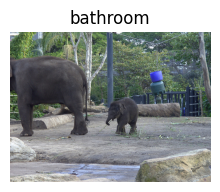


dining_room: nessuna immagine trovata

office: nessuna immagine trovata

hallway: nessuna immagine trovata

store: nessuna immagine trovata

garage: nessuna immagine trovata

outdoor: nessuna immagine trovata

street: nessuna immagine trovata

unknown: nessuna immagine trovata


In [20]:
show_images_per_room(df_new, col="obj_list", images_path= "../data/images")

In [ ]:
import clip
import torch
from PIL import Image
import os

def assign_room_clip(df, image_path_col, images_dir):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model, preprocess = clip.load("ViT-B/32", device=device)

    labels = [
        "a kitchen",
        "a bathroom",
        "a living room",
        "a bedroom",
        "an outdoor scene",
        "an office",
        "a dining room",
        "a street",
        "a store",
        "a garage"
    ]

    text = clip.tokenize(labels).to(device)

    results = []

    for _, row in df.iterrows():

        img_path = os.path.join(images_dir, row[image_path_col]+".jpg")
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)

            logits = image_features @ text_features.T
            probs = logits.softmax(dim=-1)

            pred = labels[probs.argmax().item()]

        results.append(pred)

    df["clip_room"] = results

    return df

In [ ]:
df_clip = assign_room_clip(df_new, "image_id", "../data/images")